# Personal Finance Analyzer — Data Cleaning & EDA

This notebook covers:
1. Loading the raw (deliberately messy) transaction data
2. Data cleaning — fixing dates, currency symbols, duplicates, sign errors
3. Exploratory Data Analysis (EDA) — trends, category breakdowns, outliers
4. Category prediction for missing values using a text classifier

Run top to bottom, or just read through — every cell below has already
been executed once so you can see the actual output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Load Raw Data

The raw CSV was generated synthetically but with realistic messiness
injected on purpose — mixed date formats, missing values, duplicate rows,
inconsistent casing, currency symbols, and a few sign errors.

In [2]:
df_raw = pd.read_csv("data/transactions.csv")
print("Shape:", df_raw.shape)
df_raw.head(10)


Shape: (792, 6)


In [3]:
print("Missing values per column:")
print(df_raw.isna().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())
print()
print("Sample of currency-symbol noise in Amount column:")
print(df_raw[df_raw["Amount"].astype(str).str.contains("₹", na=False)][["Description", "Amount"]].head(5))


Missing values per column:
Date            0
Description     0
Amount         16
Type            0
Category       95
PaymentMode     0
dtype: int64

Duplicate rows: 13

Sample of currency-symbol noise in Amount column:
            Description    Amount
5   Metro Card Recharge   ₹194.55
9    Local Kirana Store    ₹503.4
57            Groww SIP   ₹8298.7
60   Local Kirana Store    ₹547.2
76              Blinkit  ₹2173.44


In [4]:
print("Category casing/whitespace inconsistency — unique variants:")
print(sorted(df_raw["Category"].dropna().unique().tolist())[:15])
print()
print("Sample raw Date values (note the mixed formats):")
print(df_raw["Date"].head(10).tolist())


Category casing/whitespace inconsistency — unique variants:
['  Bills  ', '  Education  ', '  Entertainment  ', '  Food  ', '  Health  ', '  Investment  ', '  Rent  ', '  Shopping  ', 'BILLS', 'Bills', 'Bills ', 'Education', 'Entertainment', 'Entertainment ', 'FOOD']

Sample raw Date values (note the mixed formats):
['03/19/2026', '2025-11-28', '07-06-2026', '2025-09-05', '06-03-2026', '04-12-2025', '05/06/2026', '09-04-2026', '2026-03-30', '2026-05-30']


## 2. Data Cleaning

Each fix below addresses one specific issue found above.

### 2.1 Parsing mixed date formats

The raw data mixes three formats: `%d-%m-%Y`, `%m/%d/%Y`, `%Y-%m-%d`.

**Important lesson learned while building this**: `pd.to_datetime(...,
format="mixed", dayfirst=True)` looked like the "easy" solution but it
silently mis-parsed ambiguous strings (e.g. confusing day/month order),
scrambling some dates into the wrong month. Since the three formats here
are actually distinguishable by their separator and digit pattern, a
deterministic parser is used instead — safer than letting pandas guess.

In [5]:
def parse_date(val):
    if pd.isna(val):
        return pd.NaT
    s = str(val).strip()
    try:
        if "/" in s:
            return pd.to_datetime(s, format="%m/%d/%Y")
        first_group = s.split("-")[0]
        if len(first_group) == 4:
            return pd.to_datetime(s, format="%Y-%m-%d")
        return pd.to_datetime(s, format="%d-%m-%Y")
    except (ValueError, TypeError):
        return pd.NaT

df = df_raw.copy()
df["Date"] = df["Date"].apply(parse_date)
print("Unparseable dates:", df["Date"].isna().sum())
print("Date range after parsing:", df["Date"].min(), "to", df["Date"].max())


Unparseable dates: 0
Date range after parsing: 2025-09-01 00:00:00 to 2026-06-30 00:00:00


### 2.2 Cleaning the Amount column

Strips `₹` symbols and commas, converts to float.

In [6]:
import re

def clean_amount(val):
    if pd.isna(val):
        return None
    if isinstance(val, (int, float)):
        return float(val)
    cleaned = re.sub(r"[₹,\s]", "", str(val))
    try:
        return float(cleaned)
    except ValueError:
        return None

df["Amount"] = df["Amount"].apply(clean_amount)
print("Missing amounts after cleaning:", df["Amount"].isna().sum())
print("These rows will be dropped (can't reliably impute a transaction value):")
df[df["Amount"].isna()].head(3)


Missing amounts after cleaning: 16
These rows will be dropped (can't reliably impute a transaction value):


In [7]:
df = df.dropna(subset=["Amount"])
print("Rows remaining:", len(df))


Rows remaining: 776


### 2.3 Fixing sign errors

A few Debit transactions had negative amounts entered by mistake — these
should always be a positive magnitude.

In [8]:
debit_mask = df["Type"] == "Debit"
n_negative = (df.loc[debit_mask, "Amount"] < 0).sum()
print(f"Negative Debit amounts found: {n_negative}")
df.loc[debit_mask, "Amount"] = df.loc[debit_mask, "Amount"].abs()
print("Fixed.")


Negative Debit amounts found: 7
Fixed.


### 2.4 Normalising Category text

`'  FOOD '`, `'food'`, and `'Food'` should all become `'Food'`.

In [9]:
def normalise_category(val):
    if pd.isna(val):
        return None
    return str(val).strip().title()

df["Category"] = df["Category"].apply(normalise_category)
print("Category values now:", sorted(df["Category"].dropna().unique().tolist()))


Category values now: ['Bills', 'Education', 'Entertainment', 'Food', 'Groceries', 'Health', 'Income', 'Investment', 'Rent', 'Shopping', 'Transport']


### 2.5 Removing duplicate rows

In [10]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_dupes}")
df = df.drop_duplicates()
print(f"Rows after dedup: {len(df)}")


Exact duplicate rows found: 19
Rows after dedup: 757


In [11]:
df["Description"] = df["Description"].str.strip()
df = df.sort_values("Date").reset_index(drop=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

print("Final cleaned shape:", df.shape)
print("Remaining missing Category (intentionally left for the classifier below):", df["Category"].isna().sum())
df.to_csv("data/transactions_clean.csv", index=False)
df.head(10)


Final cleaned shape: (757, 9)
Remaining missing Category (intentionally left for the classifier below): 88


## 3. Exploratory Data Analysis (EDA)

In [12]:
total_spend = df[df["Type"] == "Debit"]["Amount"].sum()
total_income = df[df["Type"] == "Credit"]["Amount"].sum()
print(f"Total spend (Debit):  Rs. {total_spend:,.2f}")
print(f"Total income (Credit): Rs. {total_income:,.2f}")
print()
print("Spend by category:")
print(df[df["Type"] == "Debit"].groupby("Category")["Amount"].sum().sort_values(ascending=False))


Total spend (Debit):  Rs. 1,227,126.84
Total income (Credit): Rs. 488,365.55

Spend by category:
Category
Shopping         333089.66693
Investment       172257.53000
Rent             160000.00000
Groceries        120775.30000
Bills             76249.33000
Health            74702.34000
Education         67054.84000
Food              47560.33000
Transport         28850.18000
Entertainment     20243.96000
Name: Amount, dtype: float64


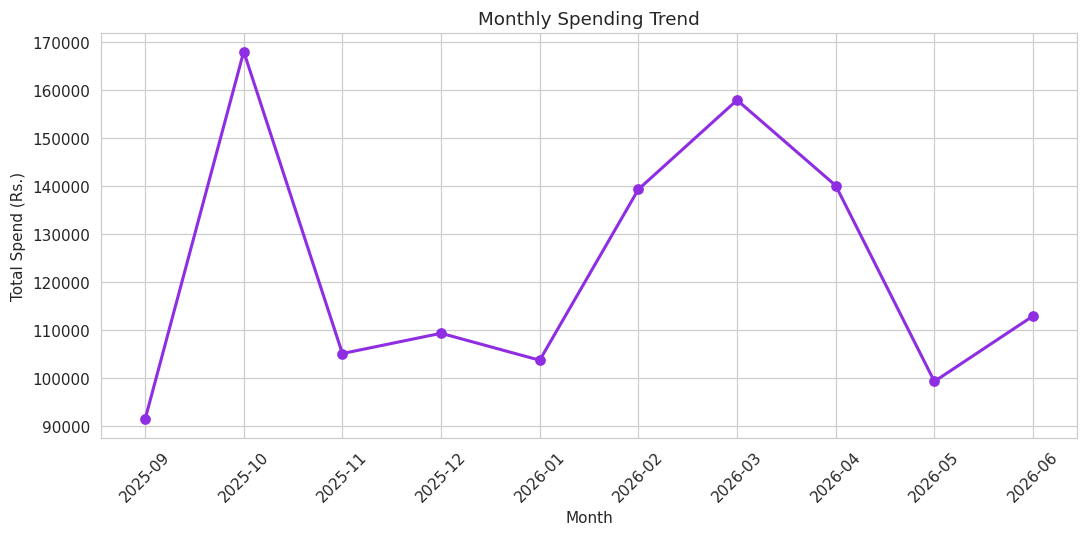

In [13]:
monthly = df[df["Type"] == "Debit"].groupby("YearMonth")["Amount"].sum().reset_index()
plt.figure()
plt.plot(monthly["YearMonth"], monthly["Amount"], marker="o", color="#8E2DE2", linewidth=2)
plt.xticks(rotation=45)
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spend (Rs.)")
plt.tight_layout()
plt.show()


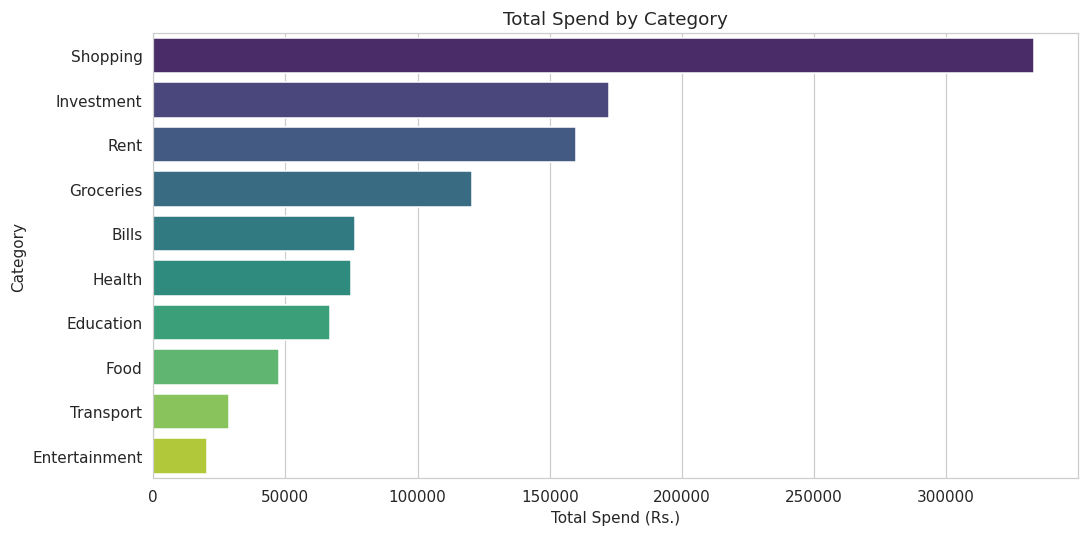

In [14]:
cat_spend = df[df["Type"] == "Debit"].groupby("Category")["Amount"].sum().sort_values(ascending=False)
plt.figure()
sns.barplot(x=cat_spend.values, y=cat_spend.index, hue=cat_spend.index, palette="viridis", legend=False)
plt.title("Total Spend by Category")
plt.xlabel("Total Spend (Rs.)")
plt.tight_layout()
plt.show()


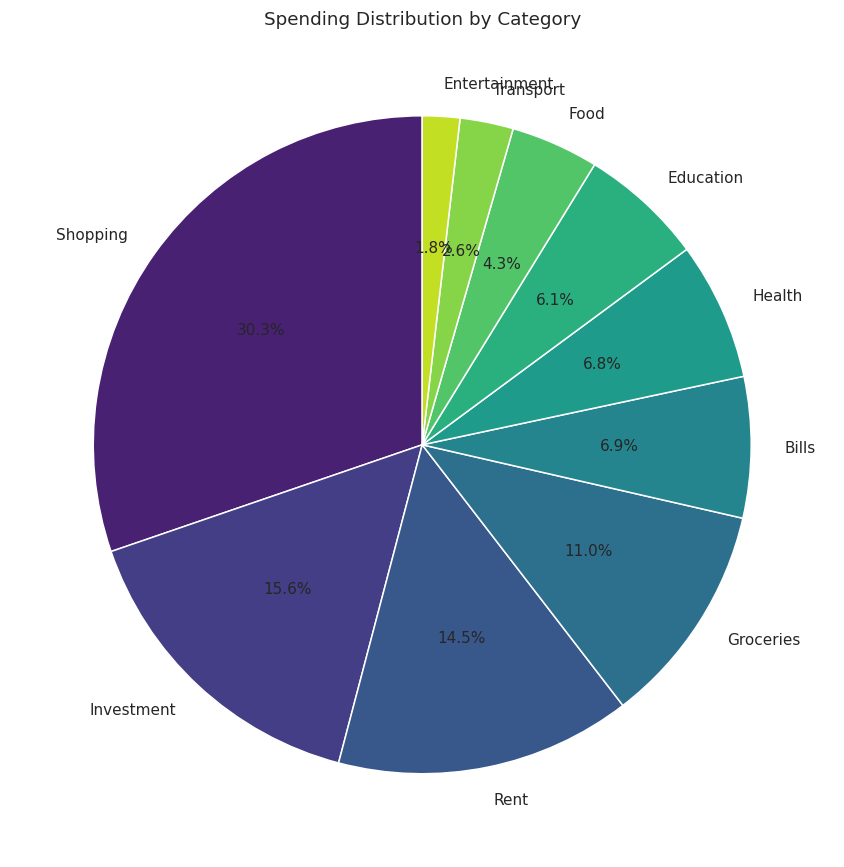

In [15]:
plt.figure(figsize=(8, 8))
plt.pie(cat_spend.values, labels=cat_spend.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("viridis", len(cat_spend)))
plt.title("Spending Distribution by Category")
plt.tight_layout()
plt.show()


### Outlier check

The boxplot below should visibly show a few outlier points far past the
whisker — these are the injected "big one-time purchase" transactions.

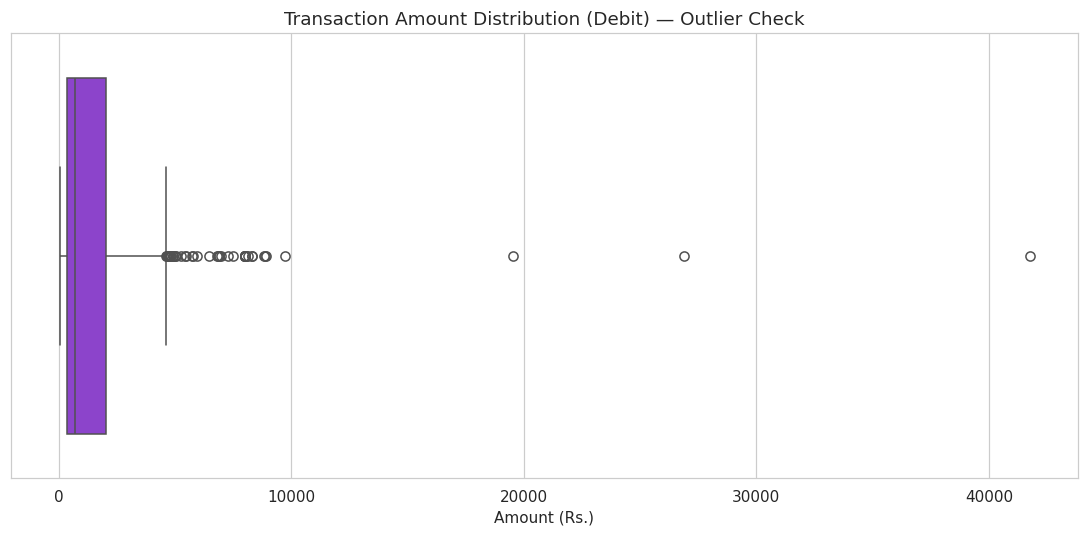

In [16]:
plt.figure()
sns.boxplot(x=df[df["Type"] == "Debit"]["Amount"], color="#8E2DE2")
plt.title("Transaction Amount Distribution (Debit) — Outlier Check")
plt.xlabel("Amount (Rs.)")
plt.tight_layout()
plt.show()


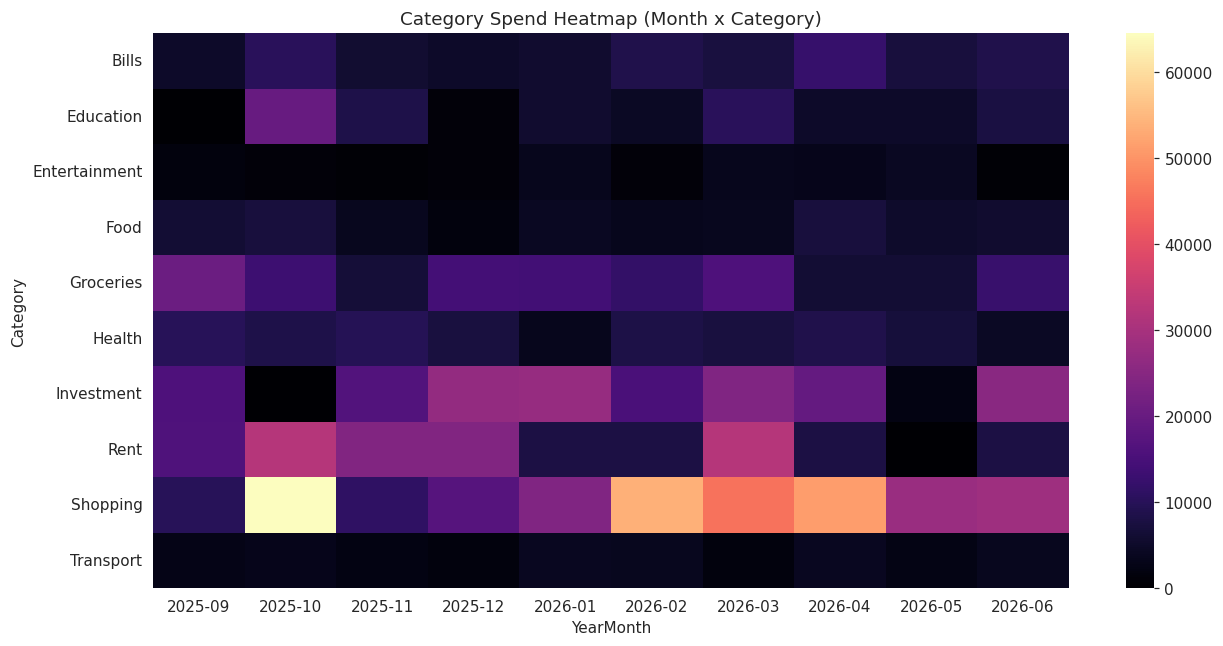

In [17]:
pivot = df[df["Type"] == "Debit"].pivot_table(
    index="Category", columns="YearMonth", values="Amount", aggfunc="sum", fill_value=0
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="magma", annot=False)
plt.title("Category Spend Heatmap (Month x Category)")
plt.tight_layout()
plt.show()


## 4. Filling Missing Categories with a Text Classifier

The `Category` column still has missing values on purpose — imputing it
from the `Description` text is a genuine ML task (TF-IDF + Linear SVM),
not just a cleaning step, so it's kept separate and shown explicitly here.

**Character n-grams** are used instead of word-level tokens because
merchant names have casing/spacing noise (`"SWIGGY"`, `"swiggy  "`,
`"Zomato*Order"`) — character n-grams stay robust to that without manual
regex cleanup of every variant.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def normalise_description(text):
    return str(text).lower().replace("*", " ").strip()

df["DescClean"] = df["Description"].apply(normalise_description)

labeled = df[df["Category"].notna()].copy()
unlabeled = df[df["Category"].isna()].copy()
print(f"Labeled rows (training data): {len(labeled)}")
print(f"Unlabeled rows (to predict): {len(unlabeled)}")


Labeled rows (training data): 669
Unlabeled rows (to predict): 88


In [19]:
X = labeled["DescClean"]
y = labeled["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1)),
    ("clf", LinearSVC(random_state=42)),
])
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Held-out test accuracy: {acc:.2%}")
print()
print(classification_report(y_test, y_pred, zero_division=0))


Held-out test accuracy: 100.00%

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00        14
    Education       1.00      1.00      1.00         5
Entertainment       1.00      1.00      1.00        10
         Food       1.00      1.00      1.00        28
    Groceries       1.00      1.00      1.00        17
       Health       1.00      1.00      1.00         9
       Income       1.00      1.00      1.00         3
   Investment       1.00      1.00      1.00         6
         Rent       1.00      1.00      1.00         4
     Shopping       1.00      1.00      1.00        18
    Transport       1.00      1.00      1.00        20

     accuracy                           1.00       134
    macro avg       1.00      1.00      1.00       134
 weighted avg       1.00      1.00      1.00       134



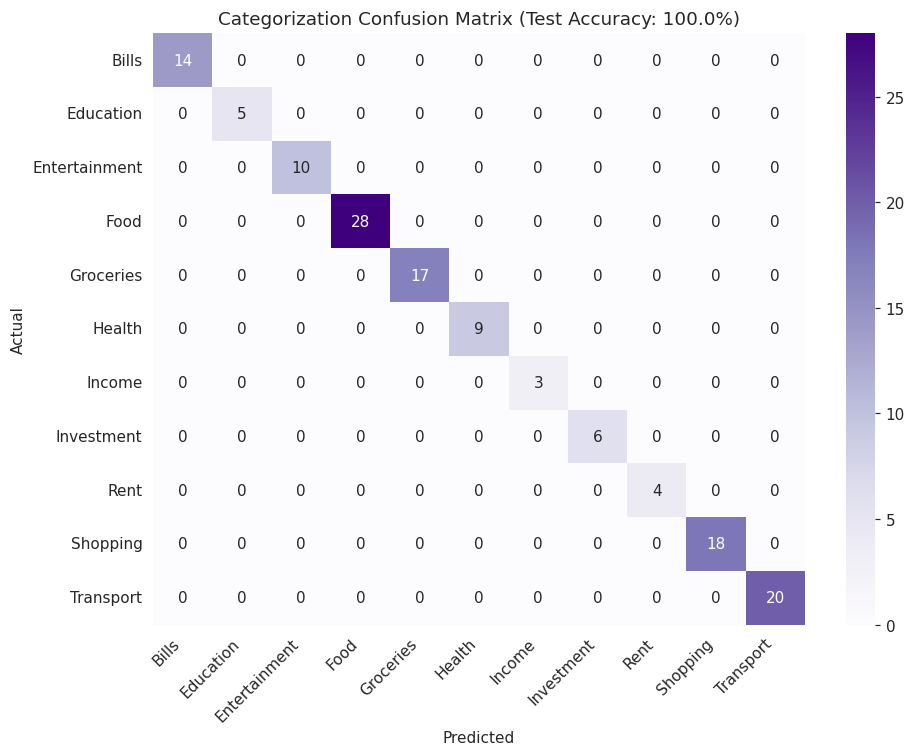

In [20]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Categorization Confusion Matrix (Test Accuracy: {acc:.1%})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Note on the near-perfect accuracy:** this reflects the synthetic
dataset's clean 1:1 merchant-to-category mapping (e.g. "Swiggy" is always
Food). Real-world data would have ambiguous merchants and typos, so
accuracy would likely be lower — that's expected, not a red flag.

In [21]:
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1)),
    ("clf", LinearSVC(random_state=42)),
])
final_pipeline.fit(X, y)

if len(unlabeled) > 0:
    predicted = final_pipeline.predict(unlabeled["DescClean"])
    df.loc[df["Category"].isna(), "Category"] = predicted
    df.loc[unlabeled.index, "CategoryPredicted"] = True

df["CategoryPredicted"] = df.get("CategoryPredicted", False).fillna(False)
df_final = df.drop(columns=["DescClean"])
df_final.to_csv("data/transactions_categorized.csv", index=False)

print(f"Filled {len(unlabeled)} missing categories.")
print()
print("Sample of previously-missing rows, now filled:")
df_final[df_final["CategoryPredicted"] == True][["Description", "Category"]].head(10)


Filled 88 missing categories.

Sample of previously-missing rows, now filled:


## Summary

- Raw data: messy dates, currency symbols, duplicates, sign errors, casing issues
- After cleaning: consistent dtypes, deduplicated, normalised text
- EDA revealed monthly trend, category-wise spend, and visible outlier transactions
- Missing categories (12% of rows) filled via a TF-IDF + Linear SVM text classifier
- Output: `data/transactions_categorized.csv`, ready for forecasting (`forecast.py`) and budgeting (`budget.py`)